LET'S START WITH MODEL TRAINING ..... 

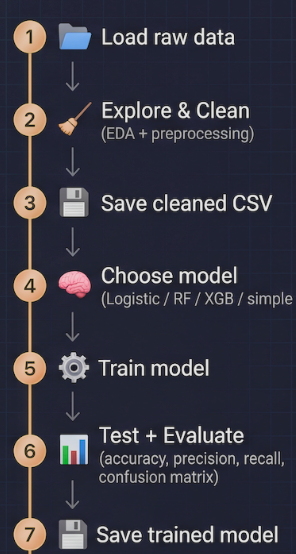

In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install sklearn
!pip install tensorflow
!pip install keras
!pip install scikit-learn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SK

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, silhouette_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings

**LOAD THE DATA**

In [21]:
df = pd.read_csv('cleaned_data.csv')

In [22]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,...,valence,tempo,time_signature,genre,mood,energy_valence,energy_minus_valence,dance_energy,acoustic_energy,mood_score
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688000,0.603000,10.000000,-6.469000,0.000000,...,0.785000,90.675000,4.000000,latin,happy,0.473355,-0.182000,0.414864,0.036127,0.701300
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777000,0.705000,7.000000,-2.432000,1.000000,...,0.715000,98.629000,4.000000,pop,happy,0.504075,-0.010000,0.547785,0.082600,0.730600
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621000,0.665000,4.000000,-5.007000,1.000000,...,0.676000,113.296000,4.000000,pop,happy,0.449540,-0.011000,0.412965,0.084085,0.656200
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,0.672000,0.944000,2.000000,-4.010000,0.000000,...,0.789000,127.822000,4.000000,electronic,happy,0.744816,0.155000,0.634368,0.001848,0.800400
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686000,0.718000,11.000000,-4.803000,0.000000,...,0.495000,135.856000,4.000000,electronic,angry,0.355410,0.223000,0.492548,0.017766,0.619200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,spotify:track:ss5cuO9CTw0NZAH1w6bfcr,Dark Night,Casey Page,The Night Diaries,78.0,0.256748,0.843139,2.069412,-6.263797,0.004754,...,0.521673,153.612092,4.117223,rock,motivational,0.439842,0.321466,0.216474,0.010220,0.538635
824,spotify:track:ff2Ct6kqGmZns4sojXNix3,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.419514,0.685676,6.519228,-1.160989,1.022559,...,0.559079,152.086661,4.969553,metal,motivational,0.383347,0.126598,0.287651,0.020519,0.555188
825,spotify:track:34RApa10bO0ZbJ30uBvMpb,Fire Soul,Taylor Lane,The Soul EP,63.0,0.479266,0.732708,6.076938,-7.092107,0.013114,...,0.500948,112.274370,3.974649,rock,motivational,0.367048,0.231759,0.351162,0.045986,0.563971
826,track_440,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.415314,0.682311,6.247195,-0.997101,0.997815,...,0.554620,153.263626,5.004233,metal,motivational,0.378423,0.127692,0.283374,0.020648,0.551135


**PART 1 : REGRESSION - Predict Song Popularity !**

A. Select features (numeric only – you can tell me which to drop)

In [23]:
print("\n=== Regression: Predict Song Popularity ===")


=== Regression: Predict Song Popularity ===


In [24]:
features_reg = ['danceability', 'energy', 'loudness', 'valence', 'tempo']

In [25]:
cols_to_drop_reg = ['key','mode','speechiness','acousticness', 'instrumentalness','liveness']

In [26]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,...,valence,tempo,time_signature,genre,mood,energy_valence,energy_minus_valence,dance_energy,acoustic_energy,mood_score
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688000,0.603000,10.000000,-6.469000,0.000000,...,0.785000,90.675000,4.000000,latin,happy,0.473355,-0.182000,0.414864,0.036127,0.701300
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777000,0.705000,7.000000,-2.432000,1.000000,...,0.715000,98.629000,4.000000,pop,happy,0.504075,-0.010000,0.547785,0.082600,0.730600
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621000,0.665000,4.000000,-5.007000,1.000000,...,0.676000,113.296000,4.000000,pop,happy,0.449540,-0.011000,0.412965,0.084085,0.656200
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,0.672000,0.944000,2.000000,-4.010000,0.000000,...,0.789000,127.822000,4.000000,electronic,happy,0.744816,0.155000,0.634368,0.001848,0.800400
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686000,0.718000,11.000000,-4.803000,0.000000,...,0.495000,135.856000,4.000000,electronic,angry,0.355410,0.223000,0.492548,0.017766,0.619200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,spotify:track:ss5cuO9CTw0NZAH1w6bfcr,Dark Night,Casey Page,The Night Diaries,78.0,0.256748,0.843139,2.069412,-6.263797,0.004754,...,0.521673,153.612092,4.117223,rock,motivational,0.439842,0.321466,0.216474,0.010220,0.538635
824,spotify:track:ff2Ct6kqGmZns4sojXNix3,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.419514,0.685676,6.519228,-1.160989,1.022559,...,0.559079,152.086661,4.969553,metal,motivational,0.383347,0.126598,0.287651,0.020519,0.555188
825,spotify:track:34RApa10bO0ZbJ30uBvMpb,Fire Soul,Taylor Lane,The Soul EP,63.0,0.479266,0.732708,6.076938,-7.092107,0.013114,...,0.500948,112.274370,3.974649,rock,motivational,0.367048,0.231759,0.351162,0.045986,0.563971
826,track_440,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.415314,0.682311,6.247195,-0.997101,0.997815,...,0.554620,153.263626,5.004233,metal,motivational,0.378423,0.127692,0.283374,0.020648,0.551135


In [27]:
X_reg = df[features_reg]

In [28]:
X_reg

,danceability,energy,loudness,valence,tempo
0,0.688000,0.603000,-6.469000,0.785000,90.675000
1,0.777000,0.705000,-2.432000,0.715000,98.629000
2,0.621000,0.665000,-5.007000,0.676000,113.296000
3,0.672000,0.944000,-4.010000,0.789000,127.822000
4,0.686000,0.718000,-4.803000,0.495000,135.856000
...,...,...,...,...,...
823,0.256748,0.843139,-6.263797,0.521673,153.612092
824,0.419514,0.685676,-1.160989,0.559079,152.086661
825,0.479266,0.732708,-7.092107,0.500948,112.274370
826,0.415314,0.682311,-0.997101,0.554620,153.263626


In [29]:
y_reg = df['popularity']

In [30]:
y_reg

0      66.0
1      77.0
2      74.0
3      66.0
4      62.0
       ... 
823    78.0
824    60.0
825    63.0
826    60.0
827    69.0
Name: popularity, Length: 828, dtype: float64

B. Train-test split !

In [31]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

C. Scaling (very important for regression)

In [16]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

D. Import Model : Model --> XGBOOST-REGRESSOR

In [32]:
!pip install xgboost
from xgboost import XGBRegressor

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)


In [33]:
xgb_reg = XGBRegressor(
    n_estimators=40,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

In [34]:
xgb_reg.fit(X_train_reg_scaled ,y_train_reg )

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [35]:
y_pred_reg = xgb_reg.predict(X_test_reg_scaled )

In [36]:
y_pred_reg 

array([45.64801 , 45.376007, 76.71309 , 45.436916, 84.57677 , 79.04902 ,
       75.7586  , 71.36474 , 72.33384 , 77.886406, 72.170364, 74.4385  ,
       82.41284 , 72.170364, 77.42954 , 45.376007, 75.31054 , 76.86338 ,
       60.552864, 45.617573, 46.558617, 78.617546, 77.867004, 45.73666 ,
       73.99397 , 61.888992, 78.27295 , 45.376007, 74.80813 , 76.9659  ,
       59.454224, 78.67569 , 76.618484, 78.18777 , 80.26884 , 47.09547 ,
       48.690056, 70.382706, 69.77188 , 74.31745 , 45.433247, 60.552864,
       79.942055, 45.32289 , 63.0722  , 75.24578 , 68.6501  , 45.436916,
       63.26046 , 72.40378 , 46.718826, 76.24296 , 52.569675, 79.31431 ,
       47.09547 , 46.32761 , 46.64748 , 45.436916, 47.09547 , 64.24193 ,
       61.24407 , 73.51202 , 52.921005, 45.752922, 77.48646 , 72.72368 ,
       61.21906 , 74.06795 , 45.376007, 65.863365, 53.356586, 75.12927 ,
       45.3499  , 73.43057 , 56.78224 , 61.21906 , 78.82747 , 74.907486,
       53.248158, 71.563644, 58.304234, 45.436916, 

In [37]:
mae_r = mean_absolute_error(y_test_reg,y_pred_reg)
rmse_r = np.sqrt(mean_absolute_error(y_test_reg, y_pred_reg)**2)  
r2_r = r2_score(y_test_reg, y_pred_reg)

In [38]:
print(f"XGBoost Regression Results:")
print(f"MAE: {mae_r:.2f}")
print(f"RMSE: {rmse_r:.2f}")
print(f"R²: {r2_r:.2f}")

XGBoost Regression Results:
MAE: 3.59
RMSE: 3.59
R²: 0.86


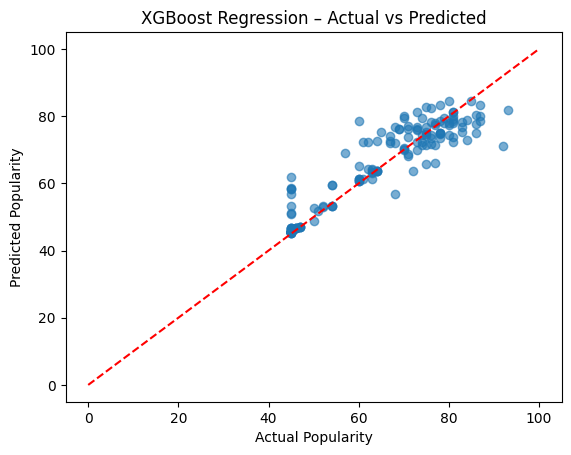

In [39]:
# Quick plot
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('XGBoost Regression – Actual vs Predicted')
plt.show()

**Lets check with the Other Regression Algorithms and find out the best Algorithms to choose .**

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [41]:
reg_models = {}

**1. Linear Regression**

In [42]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_lr = lr_reg.predict(X_test_reg_scaled)

In [43]:
reg_models['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)),
    'R2': r2_score(y_test_reg, y_pred_lr)
}

In [44]:
reg_models

{'Linear Regression': {'MAE': 6.964191588644934,
  'RMSE': np.float64(9.069048685176718),
  'R2': 0.6171537550634314}}

**2. RANDOM FOREST REGRESSION**

In [45]:
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg) 
y_pred_rf = rf_reg.predict(X_test_reg)


In [46]:
reg_models['Random Forest'] = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)),
    'R2': r2_score(y_test_reg, y_pred_rf)
}

In [47]:
reg_models

{'Linear Regression': {'MAE': 6.964191588644934,
  'RMSE': np.float64(9.069048685176718),
  'R2': 0.6171537550634314},
 'Random Forest': {'MAE': 3.2506024096385535,
  'RMSE': np.float64(5.436633880610982),
  'R2': 0.8624181643240643}}

**3. Neural Network Regressor (with scaling)**

In [48]:
nn_reg = Sequential([
    Dense(32, input_dim=X_train_reg_scaled.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')  
])

/Users/aryan/miniconda3/envs/my_ml_project/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
nn_reg.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [50]:
nn_reg.fit(
    X_train_reg_scaled, y_train_reg,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0  
)

In [51]:
y_pred_nn = nn_reg.predict(X_test_reg_scaled).flatten()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [52]:
reg_models['Neural Network'] = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_nn),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_nn)),
    'R2': r2_score(y_test_reg, y_pred_nn)
}

In [53]:
reg_models

{'Linear Regression': {'MAE': 6.964191588644934,
  'RMSE': np.float64(9.069048685176718),
  'R2': 0.6171537550634314},
 'Random Forest': {'MAE': 3.2506024096385535,
  'RMSE': np.float64(5.436633880610982),
  'R2': 0.8624181643240643},
 'Neural Network': {'MAE': 10.590259804783097,
  'RMSE': np.float64(14.03537830445967),
  'R2': 0.08304257607578736}}

In [54]:
##save the best model
import joblib   
joblib.dump(rf_reg, 'best_reg_model.pkl')

['best_reg_model.pkl']

In [55]:
## load the model
loaded_rf_reg = joblib.load('best_reg_model.pkl')

In [56]:
X_test_reg

,danceability,energy,loudness,valence,tempo
608,0.278982,0.350847,-11.795579,0.654014,76.984745
457,0.260524,0.405747,-11.422640,0.325841,107.267540
290,0.641000,0.868000,-6.748000,0.309000,142.260000
558,0.530668,0.330940,-8.738637,0.327875,104.718958
168,0.606000,0.820000,-5.303000,1.000000,124.513000
...,...,...,...,...,...
613,0.673571,0.330849,-11.844485,0.643754,107.256998
192,0.559000,0.683500,-5.955000,0.497000,115.992000
357,0.570000,0.516000,-5.942000,0.720000,96.129000
722,0.548268,0.528430,-8.102921,0.552479,142.350231


In [60]:
predicted_results = loaded_rf_reg.predict(X_test_reg)

In [61]:
max(predicted_results)

np.float64(86.6)

In [68]:
type(predicted_results)

numpy.ndarray

In [69]:
list(predicted_results).index(max(predicted_results))

155

In [70]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,...,valence,tempo,time_signature,genre,mood,energy_valence,energy_minus_valence,dance_energy,acoustic_energy,mood_score
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688000,0.603000,10.000000,-6.469000,0.000000,...,0.785000,90.675000,4.000000,latin,happy,0.473355,-0.182000,0.414864,0.036127,0.701300
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777000,0.705000,7.000000,-2.432000,1.000000,...,0.715000,98.629000,4.000000,pop,happy,0.504075,-0.010000,0.547785,0.082600,0.730600
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621000,0.665000,4.000000,-5.007000,1.000000,...,0.676000,113.296000,4.000000,pop,happy,0.449540,-0.011000,0.412965,0.084085,0.656200
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,0.672000,0.944000,2.000000,-4.010000,0.000000,...,0.789000,127.822000,4.000000,electronic,happy,0.744816,0.155000,0.634368,0.001848,0.800400
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686000,0.718000,11.000000,-4.803000,0.000000,...,0.495000,135.856000,4.000000,electronic,angry,0.355410,0.223000,0.492548,0.017766,0.619200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,spotify:track:ss5cuO9CTw0NZAH1w6bfcr,Dark Night,Casey Page,The Night Diaries,78.0,0.256748,0.843139,2.069412,-6.263797,0.004754,...,0.521673,153.612092,4.117223,rock,motivational,0.439842,0.321466,0.216474,0.010220,0.538635
824,spotify:track:ff2Ct6kqGmZns4sojXNix3,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.419514,0.685676,6.519228,-1.160989,1.022559,...,0.559079,152.086661,4.969553,metal,motivational,0.383347,0.126598,0.287651,0.020519,0.555188
825,spotify:track:34RApa10bO0ZbJ30uBvMpb,Fire Soul,Taylor Lane,The Soul EP,63.0,0.479266,0.732708,6.076938,-7.092107,0.013114,...,0.500948,112.274370,3.974649,rock,motivational,0.367048,0.231759,0.351162,0.045986,0.563971
826,track_440,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.415314,0.682311,6.247195,-0.997101,0.997815,...,0.554620,153.263626,5.004233,metal,motivational,0.378423,0.127692,0.283374,0.020648,0.551135


In [71]:
df.iloc[155]

track_id                spotify:track:kXj7tC4jLlf7byz8FoCr9g
track_name                                         Telepatia
artists                                           Kali Uchis
album_name                                         Sin Miedo
popularity                                              81.0
danceability                                           0.733
energy                                                 0.627
key                                                      5.0
loudness                                              -3.353
mode                                                     0.0
speechiness                                            0.091
acousticness                                           0.037
instrumentalness                                       0.032
liveness                                               0.117
valence                                                0.813
tempo                                                114.371
time_signature          

**In case , You want to check the Trained model , You can load the model and check it as well**

**PART-2: CLASSIFICATION : PREDICT THE MOOD USING XGBOOST**

In [72]:
from xgboost import XGBClassifier

In [73]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,...,valence,tempo,time_signature,genre,mood,energy_valence,energy_minus_valence,dance_energy,acoustic_energy,mood_score
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688000,0.603000,10.000000,-6.469000,0.000000,...,0.785000,90.675000,4.000000,latin,happy,0.473355,-0.182000,0.414864,0.036127,0.701300
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777000,0.705000,7.000000,-2.432000,1.000000,...,0.715000,98.629000,4.000000,pop,happy,0.504075,-0.010000,0.547785,0.082600,0.730600
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621000,0.665000,4.000000,-5.007000,1.000000,...,0.676000,113.296000,4.000000,pop,happy,0.449540,-0.011000,0.412965,0.084085,0.656200
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,0.672000,0.944000,2.000000,-4.010000,0.000000,...,0.789000,127.822000,4.000000,electronic,happy,0.744816,0.155000,0.634368,0.001848,0.800400
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686000,0.718000,11.000000,-4.803000,0.000000,...,0.495000,135.856000,4.000000,electronic,angry,0.355410,0.223000,0.492548,0.017766,0.619200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,spotify:track:ss5cuO9CTw0NZAH1w6bfcr,Dark Night,Casey Page,The Night Diaries,78.0,0.256748,0.843139,2.069412,-6.263797,0.004754,...,0.521673,153.612092,4.117223,rock,motivational,0.439842,0.321466,0.216474,0.010220,0.538635
824,spotify:track:ff2Ct6kqGmZns4sojXNix3,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.419514,0.685676,6.519228,-1.160989,1.022559,...,0.559079,152.086661,4.969553,metal,motivational,0.383347,0.126598,0.287651,0.020519,0.555188
825,spotify:track:34RApa10bO0ZbJ30uBvMpb,Fire Soul,Taylor Lane,The Soul EP,63.0,0.479266,0.732708,6.076938,-7.092107,0.013114,...,0.500948,112.274370,3.974649,rock,motivational,0.367048,0.231759,0.351162,0.045986,0.563971
826,track_440,B.Y.O.B.,System of a Down,Mezmerize,60.0,0.415314,0.682311,6.247195,-0.997101,0.997815,...,0.554620,153.263626,5.004233,metal,motivational,0.378423,0.127692,0.283374,0.020648,0.551135


In [74]:
features = ['danceability', 'energy', 'key', 'loudness', 'mode','speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

In [75]:
X = df[features]

In [76]:
X

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.688000,0.603000,10.000000,-6.469000,0.000000,0.107000,0.091000,0.012000,0.163000,0.785000,90.675000
1,0.777000,0.705000,7.000000,-2.432000,1.000000,0.040000,0.280000,0.030000,0.067000,0.715000,98.629000
2,0.621000,0.665000,4.000000,-5.007000,1.000000,0.049000,0.251000,0.019000,0.221000,0.676000,113.296000
3,0.672000,0.944000,2.000000,-4.010000,0.000000,0.082000,0.033000,0.116000,0.093000,0.789000,127.822000
4,0.686000,0.718000,11.000000,-4.803000,0.000000,0.088000,0.063000,0.136500,0.056000,0.495000,135.856000
...,...,...,...,...,...,...,...,...,...,...,...
823,0.256748,0.843139,2.069412,-6.263797,0.004754,0.041203,0.065155,0.136072,0.081314,0.521673,153.612092
824,0.419514,0.685676,6.519228,-1.160989,1.022559,0.110829,0.065278,0.138076,0.141243,0.559079,152.086661
825,0.479266,0.732708,6.076938,-7.092107,0.013114,0.035666,0.172045,0.101464,0.102371,0.500948,112.274370
826,0.415314,0.682311,6.247195,-0.997101,0.997815,0.110255,0.064995,0.131698,0.142320,0.554620,153.263626


**Why Label Encoding?**
- Label encoding is used to convert categorical variables into numerical format, which is essential for machine learning

In [77]:
from sklearn.preprocessing import LabelEncoder
le_mood = LabelEncoder()
y_clf = le_mood.fit_transform(df['mood'])

In [79]:
le_mood.classes_

array(['angry', 'chill', 'energetic', 'happy', 'motivational', 'relaxed',
       'sad'], dtype=object)

In [80]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [81]:
xgb_clf = XGBClassifier(
    n_estimators=13,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=1,
    eval_metric='mlogloss'
)

In [82]:
xgb_clf.fit(X_train_c, y_train_c)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [83]:
y_pred_c = xgb_clf.predict(X_test_c)

In [85]:
X_test_c

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
608,0.278982,0.350847,5.924901,-11.795579,-0.036926,0.054149,0.503062,0.028533,0.366061,0.654014,76.984745
457,0.260524,0.405747,7.852773,-11.422640,0.988862,0.078740,0.348119,0.076872,0.136780,0.325841,107.267540
290,0.641000,0.868000,6.000000,-6.748000,1.000000,0.073000,0.066000,0.056000,0.147000,0.309000,142.260000
558,0.530668,0.330940,4.836586,-8.738637,1.013757,0.047537,0.494125,0.133296,0.208738,0.327875,104.718958
168,0.606000,0.820000,9.000000,-5.303000,0.000000,0.087000,0.061000,0.136500,0.365875,1.000000,124.513000
...,...,...,...,...,...,...,...,...,...,...,...
613,0.673571,0.330849,6.625164,-11.844485,1.030033,0.075369,0.494160,0.117588,0.243745,0.643754,107.256998
192,0.559000,0.683500,1.000000,-5.955000,0.000000,0.063000,0.258000,0.039000,0.164000,0.497000,115.992000
357,0.570000,0.516000,8.000000,-5.942000,0.000000,0.040000,0.284000,0.046000,0.198000,0.720000,96.129000
722,0.548268,0.528430,4.129589,-8.102921,0.996172,0.079382,0.530439,0.007804,0.192623,0.552479,142.350231


In [84]:
y_pred_c

array([1, 6, 0, 6, 3, 0, 4, 2, 3, 0, 5, 3, 3, 5, 2, 6, 2, 0, 4, 6, 5, 3,
       3, 1, 2, 0, 3, 6, 5, 0, 2, 0, 3, 2, 2, 1, 6, 4, 1, 3, 1, 4, 3, 6,
       3, 5, 4, 1, 3, 5, 5, 0, 0, 3, 1, 5, 5, 6, 1, 3, 4, 4, 0, 1, 0, 2,
       4, 1, 6, 2, 5, 2, 1, 3, 0, 4, 0, 4, 0, 0, 4, 6, 6, 3, 3, 0, 3, 3,
       0, 1, 6, 2, 1, 3, 1, 4, 0, 3, 6, 4, 4, 5, 6, 0, 5, 3, 4, 0, 1, 4,
       3, 4, 2, 6, 6, 4, 4, 1, 0, 4, 4, 3, 1, 3, 2, 5, 1, 1, 0, 1, 6, 1,
       3, 6, 0, 2, 3, 2, 2, 2, 6, 1, 5, 3, 0, 0, 1, 0, 6, 0, 3, 4, 5, 3,
       3, 3, 6, 2, 3, 5, 4, 1, 4, 3, 5, 4])

In [86]:
print("\nXGBoost Classification Report (Mood):")
print(classification_report(y_test_c, y_pred_c, target_names=le_mood.classes_))


XGBoost Classification Report (Mood):
              precision    recall  f1-score   support

       angry       1.00      0.96      0.98        28
       chill       1.00      1.00      1.00        24
   energetic       0.83      1.00      0.91        15
       happy       1.00      0.92      0.96        37
motivational       0.96      1.00      0.98        24
     relaxed       1.00      1.00      1.00        17
         sad       1.00      1.00      1.00        21

    accuracy                           0.98       166
   macro avg       0.97      0.98      0.98       166
weighted avg       0.98      0.98      0.98       166



In [87]:
joblib.dump(xgb_clf, 'best_clf_model.pkl')

['best_clf_model.pkl']

**PART-3: LET'S LOOK INTO THE CLUSTERING PROBLEM !**

In [88]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [89]:
features = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

In [90]:
X = df[features]

In [91]:
X

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.688000,0.603000,10.000000,-6.469000,0.000000,0.107000,0.091000,0.012000,0.163000,0.785000,90.675000
1,0.777000,0.705000,7.000000,-2.432000,1.000000,0.040000,0.280000,0.030000,0.067000,0.715000,98.629000
2,0.621000,0.665000,4.000000,-5.007000,1.000000,0.049000,0.251000,0.019000,0.221000,0.676000,113.296000
3,0.672000,0.944000,2.000000,-4.010000,0.000000,0.082000,0.033000,0.116000,0.093000,0.789000,127.822000
4,0.686000,0.718000,11.000000,-4.803000,0.000000,0.088000,0.063000,0.136500,0.056000,0.495000,135.856000
...,...,...,...,...,...,...,...,...,...,...,...
823,0.256748,0.843139,2.069412,-6.263797,0.004754,0.041203,0.065155,0.136072,0.081314,0.521673,153.612092
824,0.419514,0.685676,6.519228,-1.160989,1.022559,0.110829,0.065278,0.138076,0.141243,0.559079,152.086661
825,0.479266,0.732708,6.076938,-7.092107,0.013114,0.035666,0.172045,0.101464,0.102371,0.500948,112.274370
826,0.415314,0.682311,6.247195,-0.997101,0.997815,0.110255,0.064995,0.131698,0.142320,0.554620,153.263626


Optional: scale for DBSCAN (distance-based, scaling usually helps)

In [92]:
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X)

In [101]:
db = DBSCAN(eps=2.3, min_samples=10)  
df['dbscan_cluster'] = db.fit_predict(X_scaled)

In [102]:
set(df['dbscan_cluster'])

{-1, 0, 1, 2, 3, 4}

**DBSCAN – No need to choose number of clusters !**

Number of clusters (excluding noise = -1)

In [103]:
joblib.dump(db, 'dbscan_cluster_model.pkl')

['dbscan_cluster_model.pkl']